In [2]:
import mrafit
import numpy as np
from etchingsim import fileformat
import matplotlib.pyplot as plt 
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["etching_db"]
collection = db["merged_etching_data"]


def augment_texture(v1, v2):
    if len(v1) < len(v2):
        v1 = np.append(v1, v1[-1]*np.ones(len(v2) - len(v1)))
    elif len(v2) < len(v1):
        v2 = np.append(v2, v2[-1]*np.ones(len(v1) - len(v2)))
    return v1, v2

def points_to_func(points):
    x = []
    y = []
    for i  in range(0, len(points)):
        y.append(points[i][0])
        x.append(points[i][1])
    return x, y

from etchingsim import etchingdb

collection = etchingdb.get_db_collection()
points = etchingdb.get_data(collection, '2_0.5_3_2_0')["points"]
print (points)


[[0.0, -2.499999956129175e-14, 0.0], [0.02500000037252903, -2.499999956129175e-14, 0.0], [0.05000000074505806, -2.499999956129175e-14, 0.0], [0.07500000298023224, -2.499999956129175e-14, 0.0], [0.10000000149011612, -2.499999956129175e-14, 0.0], [0.125, -2.499999956129175e-14, 0.0], [0.15000000596046448, -2.499999956129175e-14, 0.0], [0.17499999701976776, -2.499999956129175e-14, 0.0], [0.20000000298023224, -2.499999956129175e-14, 0.0], [0.22499999403953552, -2.499999956129175e-14, 0.0], [0.25, -2.499999956129175e-14, 0.0], [0.2750000059604645, -2.499999956129175e-14, 0.0], [0.30000001192092896, -2.499999956129175e-14, 0.0], [0.32499998807907104, -2.499999956129175e-14, 0.0], [0.3499999940395355, -2.499999956129175e-14, 0.0], [0.375, -2.499999956129175e-14, 0.0], [0.4000000059604645, -2.499999956129175e-14, 0.0], [0.42500001192092896, -2.499999956129175e-14, 0.0], [0.44999998807907104, -2.499999956129175e-14, 0.0], [0.4749999940395355, -2.499999956129175e-14, 0.0], [0.5, -2.4999999561291

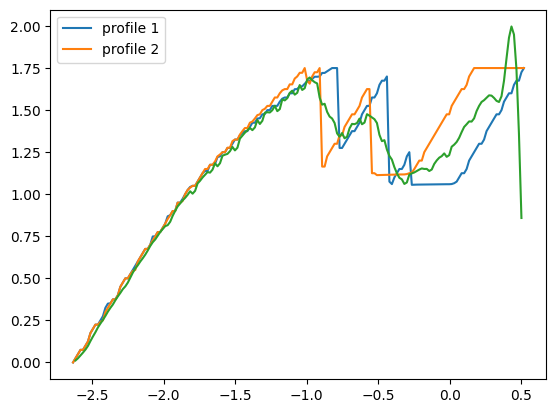

In [ ]:
points1 = doc[key1]["points"]
points2 = doc[key2]["points"]

x1, y1 = points_to_func(points1)
x2, y2 = points_to_func(points2)

y1, y2 = augment_texture(y1, y2)

# X1 = np.linspace(x1[0], x1[-1], len(y1))
# X2 = np.linspace(x2[0], x2[-1], len(y2))
X = np.linspace(min(x1[0], x2[0]), max(x1[-1], x2[-1]), max(len(y1), len(y2))) 

def func(t, y):
    i = int((t - X[0]) / (X[-1] - X[0]) * (                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             len(X) - 1))
    return y[i]

resolution=0.1
gausslet = mrafit.wavelet_bases.Gausslet_Basis(resolution)

coeffs1, approx_func1, error1 = gausslet.get_mra_approx(lambda t : func(t, y1), X)
coeffs2, approx_func2, error2 = gausslet.get_mra_approx(lambda t : func(t, y2), X)

weight = 0.5
coeffs = weight*coeffs1 + (1 - weight)*coeffs2
n_wavelets = gausslet.get_num_wavelets(X)
approx_func = np.zeros(len(X))
for i in range(0, n_wavelets):
    approx_func +=  coeffs[i] *  gausslet.get_wavefunc_data(i - int(n_wavelets/2), X)

# plt.plot(X, np.vectorize(lambda t : func(t, y1))(X), label="profile 1")
# plt.plot(X, np.vectorize(lambda t : func(t, y2))(X), label="profile 2")

plt.plot(X, np.vectorize(lambda t : func(t, y1))(X), label="profile 1")
plt.plot(X, np.vectorize(lambda t : func(t, y2))(X), label="profile 2")

a = 2
n = len(approx_func)
A = np.zeros((n - a, n))
for i in range(n - a):
    # print(A[i, i : i+a] , np.ones(a))
    A[i, i : i+a] = np.ones(a)/a

approx_func = np.matmul(A, approx_func)
plt.plot(X[int(a/2):n - int(a/2)], approx_func)    
plt.legend()

In [ ]:
from pymongo import MongoClient

# 1. Connect to MongoDB (local default)
client = MongoClient("mongodb://localhost:27017/")

# 2. Create database and collection
db = client["test_db"]
collection = db["test_collection"]

# 3. Insert a nested dictionary
data = {
    "name": "Hashida",
    "profile": {
        "age": 56,
        "city": "Osaka"
    },
    "ident": "Shiv",
    "bio": {
        "age": 29,
        "city": "Bengaluru"
    }
}
collection.insert_one(data)

# 4. Fetch one document back
doc = collection.find_one({"ident": {"$exists": True}})
# doc = collection.find()

# 5. Access values with keys
print("Name:", doc["ident"])                   # top-level key
print("Age:", doc["bio"]["age"])          # nested key
print("City:", doc["bio"]["city"])        # nested key


Name: Shiv
Age: 29
City: Bengaluru
